In [5]:
from pathlib import Path
import pandas as pd

shared_data = []
for layer_num in range(16):
    shared_path = Path(f"./identification/Llama-3.2-1B/sae_lape/layer_{layer_num}/flores_plus-shared-flores_plus/dev/shared_neurons.csv")
    if not shared_path.exists():
        continue
    df = pd.read_csv(shared_path)
    if df.empty:
        continue
    df["layer"] = layer_num
    shared_data.append(df)

# print(shared_data)
shared_all = pd.concat(shared_data, ignore_index=True)
shared_all["languages"] = shared_all["languages"].astype(str)
shared_all["num_languages"] = pd.to_numeric(shared_all["num_languages"], errors="coerce")
print(f"Loaded {len(shared_all):,} shared neurons across {shared_all['layer'].nunique()} layers.")
display(shared_all.head())


Loaded 115,703 shared neurons across 16 layers.


,feature_idx,languages,num_languages,entropy,layer
0,111157,"ja,ur",2,0.977029,0
1,45674,"en,ur",2,1.288852,0
2,11765,"en,ur",2,1.315885,0
3,96251,"ja,ur",2,1.322397,0
4,100972,"es,fr",2,1.337036,0


In [6]:
from itertools import combinations
from collections import Counter

pair_counter = Counter()

for langs in shared_all["languages"]:
    langs_list = [l.strip() for l in langs.split(",") if l.strip()]
    for pair in combinations(sorted(langs_list), 2):
        pair_counter[pair] += 1

pair_df = pd.DataFrame(pair_counter.items(), columns=["lang_pair", "count"])
pair_df["lang1"], pair_df["lang2"] = zip(*pair_df["lang_pair"])
pair_df = pair_df.sort_values("count", ascending=False)

print("Top 10 most frequently shared language pairs:")
display(pair_df.head(10))


Top 10 most frequently shared language pairs:


,lang_pair,count,lang1,lang2
2,"(es, fr)",102919,es,fr
14,"(es, it)",99478,es,it
10,"(fr, it)",98890,fr,it
8,"(es, pt)",98228,es,pt
11,"(fr, pt)",97064,fr,pt
16,"(it, pt)",96471,it,pt
6,"(en, fr)",92555,en,fr
22,"(en, es)",92517,en,es
29,"(en, it)",91465,en,it
17,"(en, pt)",90955,en,pt


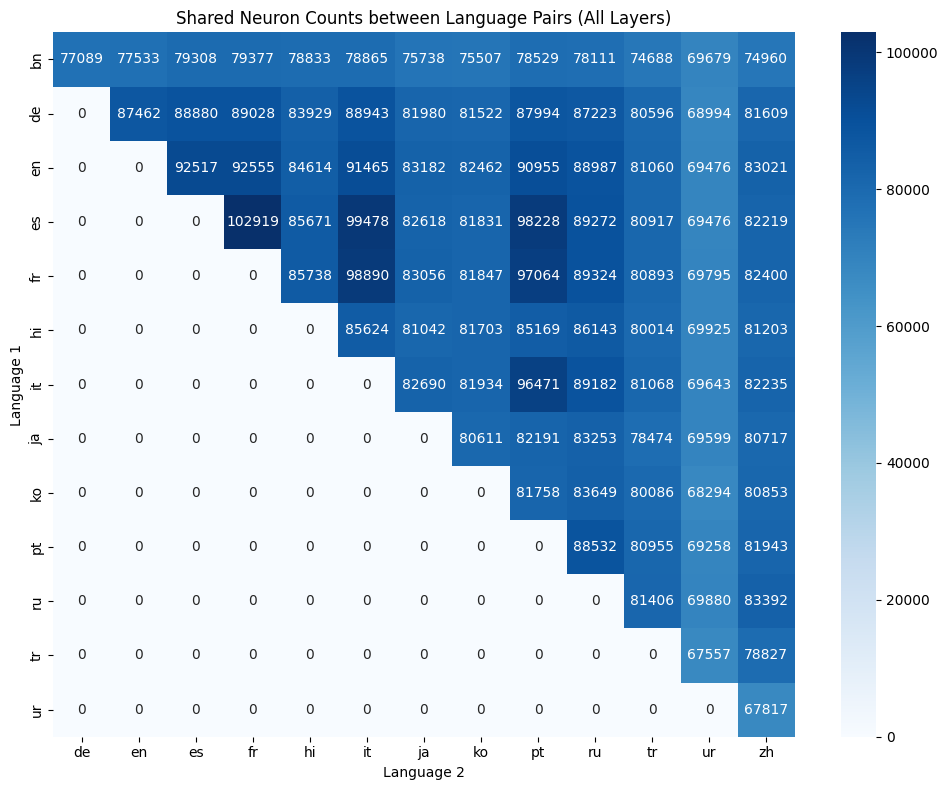

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

pivot_langs = pair_df.pivot(index="lang1", columns="lang2", values="count").fillna(0)

plt.figure(figsize=(10,8))
sns.heatmap(pivot_langs, cmap="Blues", annot=True, fmt=".0f")
plt.title("Shared Neuron Counts between Language Pairs (All Layers)")
plt.ylabel("Language 1")
plt.xlabel("Language 2")
plt.tight_layout()
plt.show()


In [16]:
from pathlib import Path
import pandas as pd

shared_data = []

for layer_num in range(16):
    shared_path = Path(f"./identification/Llama-3.2-1B/sae_lape/layer_{layer_num}/flores_plus-shared-flores_plus/dev/shared_neurons.csv")
    if not shared_path.exists():
        continue
    if shared_path.stat().st_size == 0:
        print(f"[Layer {layer_num}] Empty shared.csv — skipped.")
        continue

    try:
        df = pd.read_csv(shared_path)
        if df.empty:
            print(f"[Layer {layer_num}] shared.csv has 0 rows — skipped.")
            continue
        df["layer"] = layer_num
        shared_data.append(df)
    except Exception as e:
        print(f"[Layer {layer_num}] Failed to read {shared_path.name}: {e}")

if len(shared_data) == 0:
    raise RuntimeError("No non-empty shared.csv files found!")

shared_all = pd.concat(shared_data, ignore_index=True)
shared_all["num_languages"] = pd.to_numeric(shared_all["num_languages"], errors="coerce")
shared_all["feature_idx"] = pd.to_numeric(shared_all["feature_idx"], errors="coerce")
shared_all = shared_all.dropna(subset=["feature_idx"])
shared_all["feature_idx"] = shared_all["feature_idx"].astype(int)

print(f"✅ Loaded {len(shared_all):,} shared-neuron rows across {shared_all['layer'].nunique()} layers.")
display(shared_all.head())


✅ Loaded 115,703 shared-neuron rows across 16 layers.


,feature_idx,languages,num_languages,entropy,layer
0,111157,"ja,ur",2,0.977029,0
1,45674,"en,ur",2,1.288852,0
2,11765,"en,ur",2,1.315885,0
3,96251,"ja,ur",2,1.322397,0
4,100972,"es,fr",2,1.337036,0


In [20]:
probe_dir_root = Path("lang2vec_probing/results")
probe_data = []

for layer_num in range(2):
    probe_dir = probe_dir_root / str(layer_num) / "flores_plus-shared-flores_plus"
    if not probe_dir.exists():
        continue

    for f in probe_dir.glob("*_probes_shared.csv"):
        if f.stat().st_size == 0:
            continue
        try:
            df = pd.read_csv(f)
            if df.empty:
                continue
            df["layer"] = layer_num
            df["probe_file"] = f.name
            df["feature_set"] = f.name.split("_probes_shared.csv")[0]
            probe_data.append(df)
        except Exception as e:
            continue
            # print(f"[Layer {layer_num}] Failed to read {f.name}: {e}")

if len(probe_data) == 0:
    raise RuntimeError("No non-empty shared probe CSVs found!")

print(probes_shared_all["feature_idx"])

probes_shared_all = pd.concat(probe_data, ignore_index=True)
probes_shared_all.rename(columns={"neuron_idx": "feature_idx"}, inplace=True)
probes_shared_all["feature_idx"] = pd.to_numeric(probes_shared_all["feature_idx"], errors="coerce")
probes_shared_all["layer"] = pd.to_numeric(probes_shared_all["layer"], errors="coerce")
probes_shared_all = probes_shared_all.dropna(subset=["feature_idx", "layer"])
probes_shared_all["feature_idx"] = probes_shared_all["feature_idx"].astype(int)
probes_shared_all["layer"] = probes_shared_all["layer"].astype(int)

print(f"✅ Loaded {len(probes_shared_all):,} probe rows across {probes_shared_all['layer'].nunique()} layers.")
display(probes_shared_all.head())


           feature_idx  feature_idx
0                   24           24
1                   24           70
2                   24           71
3                   24           72
4                   24           73
...                ...          ...
127727395       130710           22
127727396       130710           23
127727397       130710           24
127727398       130710           25
127727399       130710           27

[127727400 rows x 2 columns]


TypeError: arg must be a list, tuple, 1-d array, or Series